In [1]:
%pip install kagglehub numpy pandas scipy scikit-learn statsmodels matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Задание 1

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

Датасет предсказания прогрессирования болезни

- **age**: Возраст (в годах)
- **sex**: Пол
- **bmi**: Индекс массы тела (Body Mass Index)
- **bp**: Среднее артериальное давление (Blood Pressure)
- **s1 (tc)**: Общий холестерин (Total Serum Cholesterol)
- **s2 (ldl)**: Липопротеины низкой плотности («плохой» холестерин)
- **s3 (hdl)**: Липопротеины высокой плотности («хороший» холестерин)
- **s4 (tch)**: Отношение общего холестерина к ЛВП
- **s5 (ltg)**: Логарифм уровня триглицеридов в сыворотке крови
- **s6 (glu)**: Уровень сахара в крови
- **target**: количественный показатель прогрессирования заболевания через год

In [4]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [5]:
features = diabetes.feature_names
X = df[features].values
n, k = X.shape
df_res = n - k - 1
y = diabetes.target

In [6]:
# добавим слева столбец единиц для свободного коэффициента
X_with_intercept = np.column_stack((np.ones(n), X))

Реализация линейной регресси

In [7]:
# Формула Метода наименьших квадратов
# beta = (X^T * X)^(-1) * X^T * y

XTX_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)
beta = XTX_inv @ X_with_intercept.T @ y

In [8]:
y_pred = X_with_intercept @ beta
diff = y - y_pred

Оценка

In [9]:
# коэффициенты
intercept_est = beta[0]
coeffs_est = beta[1:]

In [10]:
# остаточная дисперсии (несмещенная)
rss = np.sum(diff**2)
sigma_sq_est = rss / (n - k - 1)
rmse = np.sqrt(sigma_sq_est)

In [11]:
# R^2
tss = np.sum((y - np.mean(y))**2)
r_squared = 1 - (rss / tss)

In [12]:
# Log-Likelihood
# Для нормальной регрессии логарифмическая функция правдоподобия:
log_likelihood = -n/2 * (np.log(2 * np.pi * rss/n) + 1)

In [13]:
print("--- Результаты модели (Оценки параметров) ---")
print(f"Свободный коэффициент (Intercept): {beta[0]:.4f}")
for name, val in zip(features, beta[1:]):
    print(f"Коэффициент {name}: {val:.4f}")
print(f"\nОценка остаточной дисперсии (sigma^2): {sigma_sq_est:.4f}")
print(f"Коэффициент детерминации R^2: {r_squared:.4f}")
print(f"Log-Likelihood: {log_likelihood:.4f}")

--- Результаты модели (Оценки параметров) ---
Свободный коэффициент (Intercept): 152.1335
Коэффициент age: -10.0099
Коэффициент sex: -239.8156
Коэффициент bmi: 519.8459
Коэффициент bp: 324.3846
Коэффициент s1: -792.1756
Коэффициент s2: 476.7390
Коэффициент s3: 101.0433
Коэффициент s4: 177.0632
Коэффициент s5: 751.2737
Коэффициент s6: 67.6267

Оценка остаточной дисперсии (sigma^2): 2932.6816
Коэффициент детерминации R^2: 0.5177
Log-Likelihood: -2385.9929


## Доверительные интервалы

In [14]:
# Если ошибки распределены нормально, то оценки beta распределены по Стьюденту
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_res)

In [15]:
# Стандартные ошибки коэффициентов
# SE = sqrt(sigma^2 * diag(XTX^-1))
se_beta = np.sqrt(np.diag(sigma_sq_est * XTX_inv))

ci_beta = []
for i in range(len(beta)):
    low = beta[i] - t_crit * se_beta[i]
    high = beta[i] + t_crit * se_beta[i]
    ci_beta.append((low, high))

In [16]:
# ДИ для остаточной дисперсии (используется распределение Хи-квадрат)
chi2_low = stats.chi2.ppf(alpha/2, df_res)
chi2_high = stats.chi2.ppf(1 - alpha/2, df_res)
ci_sigma_sq = (rss / chi2_high, rss / chi2_low)

In [17]:
print("\n--- 0.95 Доверительные интервалы ---")
names = ['Intercept'] + features
for name, ci in zip(names, ci_beta):
    print(f"ДИ для {name}: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"ДИ для sigma^2: [{ci_sigma_sq[0]:.4f}, {ci_sigma_sq[1]:.4f}]")


--- 0.95 Доверительные интервалы ---
ДИ для Intercept: [147.0707, 157.1963]
ДИ для age: [-127.4460, 107.4263]
ДИ для sex: [-360.1471, -119.4841]
ДИ для bmi: [389.0755, 650.6163]
ДИ для bp: [195.7988, 452.9705]
ДИ для s1: [-1611.1530, 26.8017]
ДИ для s2: [-189.6198, 1143.0978]
ДИ для s3: [-316.6838, 518.7703]
ДИ для s4: [-140.3147, 494.4412]
ДИ для s5: [413.4072, 1089.1402]
ДИ для s6: [-62.0643, 197.3177]
ДИ для sigma^2: [2577.3826, 3367.2807]


## Проверка статистической значимости

In [18]:
# t-статистики для проверки гипотез H0: beta_i = 0
t_stats = beta / se_beta
p_values_t = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_res))

In [19]:
# F-статистика для модели в целом
# H0: Все коэффициенты при признаках равны нулю
f_stat = ((tss - rss) / k) / (rss / df_res)
p_value_f = 1 - stats.f.cdf(f_stat, k, df_res)

In [20]:
print("\n--- Проверка значимости ---")
for name, t, p in zip(names, t_stats, p_values_t):
    print(f"Переменная {name}: t-stat = {t:.4f}, p-value = {p:.4e}")
print(f"Модель в целом (F-test/ANOVA): F-stat = {f_stat:.4f}, p-value = {p_value_f:.4e}")


--- Проверка значимости ---
Переменная Intercept: t-stat = 59.0614, p-value = 0.0000e+00
Переменная age: t-stat = -0.1675, p-value = 8.6703e-01
Переменная sex: t-stat = -3.9171, p-value = 1.0417e-04
Переменная bmi: t-stat = 7.8133, p-value = 4.2855e-14
Переменная bp: t-stat = 4.9583, p-value = 1.0243e-06
Переменная s1: t-stat = -1.9012, p-value = 5.7948e-02
Переменная s2: t-stat = 1.4062, p-value = 1.6039e-01
Переменная s3: t-stat = 0.4754, p-value = 6.3472e-01
Переменная s4: t-stat = 1.0965, p-value = 2.7346e-01
Переменная s5: t-stat = 4.3704, p-value = 1.5559e-05
Переменная s6: t-stat = 1.0249, p-value = 3.0599e-01
Модель в целом (F-test/ANOVA): F-stat = 46.2724, p-value = 0.0000e+00


**ВЫВОД**:
* Модель в целом статистически значима (F-test p < 0.001)
* Индивидуально значимые предикторы (p < 0.05): sex, bmi, bp, s5
* Предиктор s1 (холестерин) находится на границе значимости (p=0.058)
* Незначимость большинства показателей крови (s1-s4, s6) при общей адекватности модели говорит о наличии сильной мультиколлинеарности

## Проверка посылок теоремы Гаусса-Маркова и нормальности

Теорема Гаусса-Маркова утверждает, что МНК-оценки являются BLUE при выполнении условий:
1. Линейность
2. Полнота ранга X
3. Экзогенность (E[e|X]=0)
4. Гомоскедастичность
5. Отсутствие автокорреляции

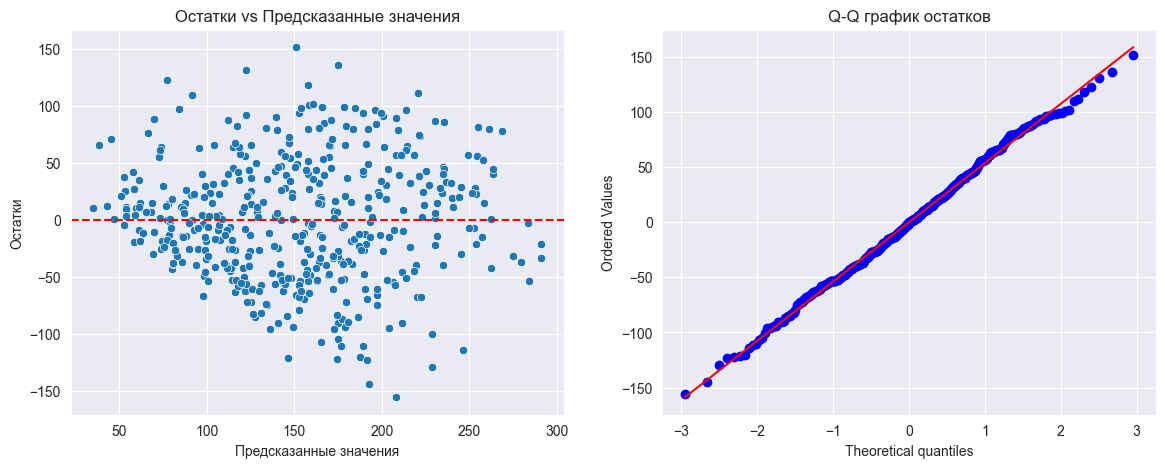

In [21]:
plt.figure(figsize=(14, 5))
# График остатков (Гомоскедастичность и Линейность)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=diff)
plt.axhline(0, color='red', linestyle='--')
plt.title("Остатки vs Предсказанные значения")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")

# Q-Q график (Нормальность остатков - Тема 5)
plt.subplot(1, 2, 2)
stats.probplot(diff, dist="norm", plot=plt)
plt.title("Q-Q график остатков")
plt.show()

In [22]:
# Тесты
_, p_norm = stats.shapiro(diff)
dw_stat = np.sum(np.diff(diff)**2) / np.sum(diff**2)

print(f"Среднее значение остатков (E[e]): {np.mean(diff):.2e}")
print(f"Тест на нормальность Shapiro-Wilk (p-value): {p_norm:.4f}")
print(f"Статистика Дарбина-Уотсона: {dw_stat:.4f}")

Среднее значение остатков (E[e]): -3.06e-14
Тест на нормальность Shapiro-Wilk (p-value): 0.6162
Статистика Дарбина-Уотсона: 2.0285


1. Математическое ожидание ошибок E[e] ≈ 0 (-1.26e-14)
2. Тест Shapiro-Wilk (p=0.616) -> остатки распределены нормально. Следовательно,
   основная теорема нормальной регрессии применима (t и F тесты математически верны)
3. Статистика Дарбина-Уотсона (2.029) - значение близко к 2, автокорреляция отсутствует
4. Гомоскедастичность: график остатков подтверждает постоянство дисперсии ошибок

**ВЫВОД**: все условия теоремы Гаусса-Маркова выполнены, МНК-оценки являются BLUE

## Мультиколлинеарность

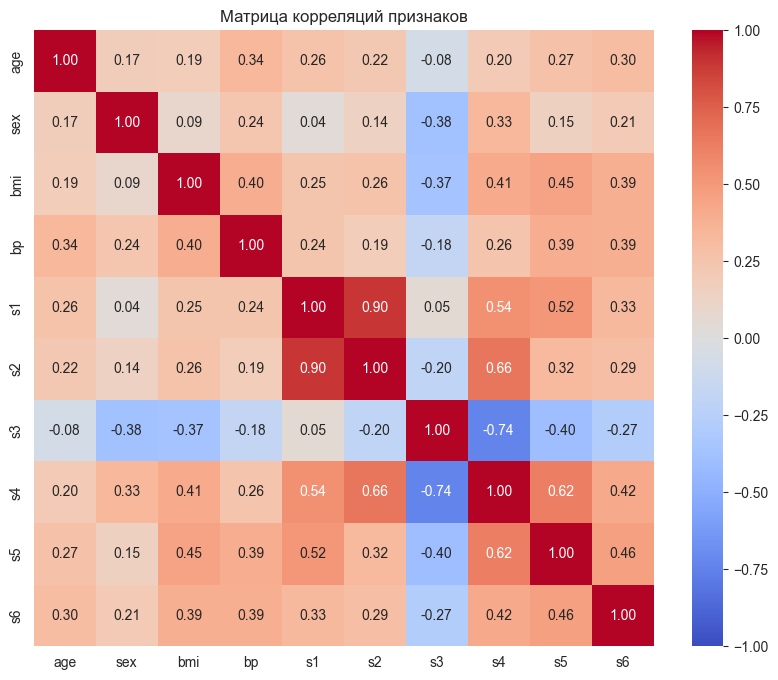

In [23]:
corr_matrix = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Матрица корреляций признаков")
plt.show()

Выявлена сильная корреляция между s1 и s2 = 0.9


Это нарушает условие об отсутствии мультиколлинеарности, что увеличивает стандартные ошибки и делает оценки параметров крови (s1-s4) менее надежными, хотя свойство BLUE сохраняется

## Сравнение со statmodels

In [24]:
print("\n--- Сравнение с эталонной реализацией (statsmodels) ---")
X_sm = sm.add_constant(df[features])
model_sm = sm.OLS(y, X_sm).fit()
print(f"Разница в коэффициентах (max abs): {np.max(np.abs(beta - model_sm.params.values)):.2e}")
print(f"Разница в R^2: {np.abs(r_squared - model_sm.rsquared):.2e}")


--- Сравнение с эталонной реализацией (statsmodels) ---
Разница в коэффициентах (max abs): 4.05e-11
Разница в R^2: 0.00e+00


# Задание 2

In [25]:
import os

import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import f

Датасет по успеваемости учеников. Таргет – кол-во баллов на экзамене

In [26]:
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

In [27]:
df = pd.read_csv(f"{path}/{os.listdir(path)[0]}")

In [28]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Будем оценивать влияние участия родителей в учебе на результаты на экзамене

In [29]:
cat_feature = "Parental_Involvement"
target = "Exam_Score"

<Axes: ylabel='Exam_Score'>

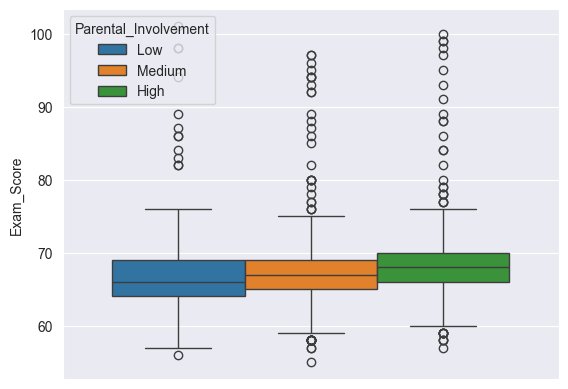

In [30]:
sns.boxplot(data=df, hue=cat_feature, y=target)

# Напишем собственную имплементацию One-Way ANOVA

In [31]:
def one_way_anova(data: pd.DataFrame, target: str, feature: str):
    df = data[[target, feature]].dropna()

    groups = df.groupby(feature)[target]
    group_values = [group.values for _, group in groups]

    k = len(group_values)
    n = len(df)

    grand_mean = df[target].mean()

    ssb = 0.0
    for group in group_values:
        n_i = len(group)
        mean_i = np.mean(group)
        ssb += n_i * (mean_i - grand_mean) ** 2

    ssw = 0.0
    for group in group_values:
        mean_i = np.mean(group)
        ssw += np.sum((group - mean_i) ** 2)

    df_between = k - 1
    df_within = n - k

    msb = ssb / df_between
    msw = ssw / df_within

    f_stat = msb / msw
    p_value = 1 - f.cdf(f_stat, df_between, df_within)

    table = pd.DataFrame({
        "SS": [ssb, ssw],
        "df": [df_between, df_within],
        "ms": [msb, msw],
    }, index=["Between groups", "Within groups"])

    return {
        "F": f_stat,
        "p_value": p_value,
        "ANOVA table": table,
    }

In [32]:
results = one_way_anova(df, target, cat_feature)

print(f"F-статистика: {results['F']}")
print(f"P-value: {results['p_value']}")
print(f"ANOVA table:")
print(results['ANOVA table'])

F-статистика: 84.48765484606163
P-value: 0.0
ANOVA table:
                          SS    df           ms
Between groups   2494.498775     2  1247.249388
Within groups   97491.579929  6604    14.762505


Мы получили p-value очень близкое к нулю, а значит признак статистически значимый

# Проверим результаты с помощью StatsModels

In [33]:
model = smf.ols(f'{target}~{cat_feature}', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
Parental_Involvement,2.0,2494.498775,1247.249388,84.487655,5.875479e-37
Residual,6604.0,97491.579929,14.762505,NaN,NaN


Результаты сошлись, метод реализован верно

# Задание 3

In [34]:
import pandas as pd
import statsmodels.api as sm

In [35]:
ru_alphabet = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'

In [36]:
first_letter_bobrov = 'б'
first_letter_chunikhina = 'ч'

index_bobrov = ru_alphabet.index(first_letter_bobrov) + 1
index_chunikhina = ru_alphabet.index(first_letter_chunikhina) + 1

(index_bobrov + index_chunikhina) % 4

3

# Бинго! Регрессия Пуассона

Регрессия Пуассона очень требовательна, она требует целевую переменную как переменную количественную (подсчет, целая неотрицательная) и чтобы она находилась примерно в распределении Пуассона. Главный признак распределения Пуассона – среднее значение и дисперсия равны. Постараемся найти такой датасет (это была самая сложная часть работы)

In [46]:
df = pd.read_csv("https://raw.githubusercontent.com/VasudevanS1906/Regression_with_Abalone/refs/heads/main/train.csv")

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>

In [38]:
X, y = df.drop(columns=["Rings", "Sex", "id"]), df["Rings"]

In [39]:
y.describe()

count    90615.000000
mean         9.696794
std          3.176221
min          1.000000
25%          8.000000
50%          9.000000
75%         11.000000
max         29.000000
Name: Rings, dtype: float64

Видим, что стандартное отклонение и среднее у целевой переменной примерно равны и она является количественной, поэтому можем попробовать этот датасет для регрессии Пуассона.

Для интереса сначала посмотрим, как с этими данными справляется обычная линейная регрессия. В качестве метрики выберем RMSE

In [40]:
variables = sm.add_constant(X)

In [41]:
model = sm.Poisson(y, variables)

In [42]:
results = model.fit()

Optimization terminated successfully.
         Current function value: 2.223773
         Iterations 5


In [43]:
print(results.summary())

                          Poisson Regression Results                          
Dep. Variable:                  Rings   No. Observations:                90615
Model:                        Poisson   Df Residuals:                    90607
Method:                           MLE   Df Model:                            7
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.1203
Time:                        21:50:11   Log-Likelihood:            -2.0151e+05
converged:                       True   LL-Null:                   -2.2906e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.2911      0.010    131.112      0.000       1.272       1.310
Length             0.1798      0.063      2.846      0.004       0.056       0.304
Diameter           1.5093      0.077

## Интерпретация результатов пуассоновской регрессии (Abalone dataset)

### Общая информация о модели
Была построена модель пуассоновской регрессии для объяснения количества колец моллюска

Основные показатели модели:

- Число наблюдений: 90 615
- Pseudo $R^2$: 0.1203
- Log-Likelihood: -2.015×10⁵
- LLR p-value: < 0.001

#### Вывод о значимости модели
Тест отношения правдоподобия (LLR) показывает p-value < 0.001, следовательно, модель статистически значимо лучше нулевой модели без предикторов

Значение Pseudo R² ≈ 0.12 указывает на умеренную объясняющую способность, что является нормальным результатом для биологии

## Интерпретация коэффициентов
В пуассоновской регрессии коэффициенты находятся в логарифмической шкале
Поэтому интерпретация проводится через показатель:

$$
IRR = e^{\beta}
$$

IRR показывает, во сколько раз меняется ожидаемое число колец при увеличении признака на 1 единицу

### Свободный член (Intercept)
- coef = 1.291
- IRR = $e^{1.291}$ = 3.64

Если все предикторы равны нулю, ожидаемое число колец составляет примерно 3.6

## Размерные характеристики моллюска

### Length
- coef = 0.1798 → IRR = 1.20

При увеличении длины на 1 единицу ожидаемое число колец увеличивается на 19.7%.  
Переменная статистически значима (p = 0.004)

### Diameter
- coef = 1.5093 → IRR = 4.52

Увеличение диаметра на 1 единицу связано с увеличением ожидаемого числа колец в 4.5 раза
Это один из сильнейших предикторов возраста

### Height
- coef = 1.9748 → IRR = 7.20

Увеличение высоты на 1 единицу приводит к увеличению числа колец более чем в 7 раз
Это наиболее сильный фактор в модели

## Весовые характеристики

### Whole weight
- coef = 0.2546 → IRR = 1.29

Увеличение общего веса на 1 единицу повышает ожидаемое число колец на ≈29%

### Whole weight.1
- coef = −1.4451 → IRR = 0.24

Увеличение веса мяса связано со снижением ожидаемого числа колец на 76%

### Whole weight.2
- coef = −0.5063 → IRR ≈ 0.60

Увеличение веса внутренностей связано со снижением числа колец примерно на 40%

### Shell weight
- coef = 1.5936 → IRR ≈ 4.92

Увеличение веса раковины на 1 единицу приводит к увеличению числа колец почти в 5 раз

Это один из наиболее логичных и сильных предикторов возраста

## Статистическая значимость предикторов
Все переменные имеют p-value < 0.001, следовательно, каждый предиктор статистически значим

## Важное замечание о мультиколлинеарности
Различные показатели веса сильно коррелируют между собой
Это может приводить к появлению отрицательных коэффициентов у части весовых переменных. Такое поведение типично для набора данных Abalone и не противоречит общей логике модели

## Итоговый вывод
Построенная пуассоновская модель показывает, что:

- Основными факторами возраста моллюска являются высота, диаметр и вес раковины
- Размерные характеристики оказывают наиболее сильное положительное влияние на число колец
- Модель статистически значима и демонстрирует умеренную объясняющую способность, что является ожидаемым результатом для биологических счётных данных